In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal, optimize
from scipy.interpolate import interp1d
from scipy.odr import ODR, Model, RealData
from scipy.special import factorial
from scipy.integrate import quad
import re

In [26]:
def load_spectrum(path):

    text = Path(path).read_text(encoding='utf-8', errors='ignore').splitlines()
    channels = []
    counts = []

    for line in text:
        match = re.match(r'\s*(\d+),\s*(\d+)', line)
        if match:
            channels.append(float(match.group(1)))
            counts.append(float(match.group(2)))
    
    return np.array(channels), np.array(counts)

def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def poisson(x, lamb):
    return (lamb ** x) * np.exp(-lamb) / factorial(x)

def compute_stat(canais, contagens, model=None):
    c = np.array(canais)
    N = np.array(contagens)

    N_t = np.sum(N)
    if N_t == 0:
        return 0, 0, None
    
    match model:
        case 'gaussian':
            popt, _ = optimize.curve_fit(gaussian, c, N, p0=[N_t, c[np.argmax(N)], np.std(c)])
            mu = popt[1]
            sigma = popt[2]/np.sqrt(N_t)
            y_fit = gaussian(c, *popt)
            dof = len(c) - 3
            chi2 = compute_chi2(N, y_fit, dof=dof)
            return mu, sigma, chi2
        case 'poisson':
            popt, _ = optimize.curve_fit(poisson, c, N, p0=[N_t/len(canais)])
            mu = popt[0]
            sigma = np.sqrt(mu/N_t)
            y_fit = poisson(c, *popt)
            dof = len(c) - 1
            chi2 = compute_chi2(N, y_fit, dof=dof)
            return mu, sigma, chi2
        case None:
            mu = np.sum(c * N) / N_t    
            sigma = np.sqrt(np.sum((c - mu) ** 2 * N)) / N_t

            return mu, sigma, float('nan')  

def compute_chi2(o, e, dof=None):
    mask = e > 0
    chi2 = np.sum(((o[mask] - e[mask]) ** 2) / e[mask])
    if dof is not None:
        return chi2 / dof
    return chi2

def linear(x, m, b):
        return m * x + b 

# Valores a 10 casas decimais
M_CALIB = 0.0053690352
B_CALIB = 0.0235248553
M_CALIB_SIGMA = 0.0000648034
B_CALIB_SIGMA = 0.0072530131

def calib(channels, sigma_channels=None):
    energy = linear(channels, M_CALIB, B_CALIB)
    if sigma_channels is not None:
        sigma_energy = np.sqrt((M_CALIB_SIGMA * channels)**2 + (M_CALIB * sigma_channels)**2 + B_CALIB_SIGMA**2)
    else:
         sigma_energy = np.sqrt((M_CALIB_SIGMA * channels)**2 + B_CALIB_SIGMA**2)
    return energy, sigma_energy

# Espessura e $\partial_x E$

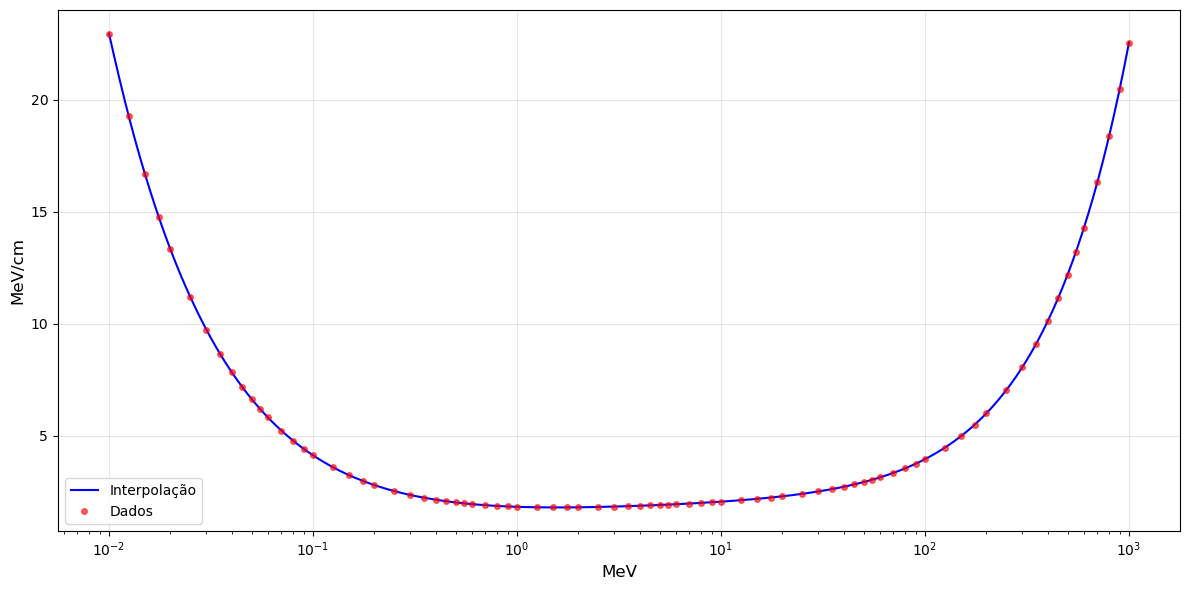

Δx = 0.050079 ± 0.002201 cm


In [27]:
rho = 9.40000e-01 #g/cm³

energy = np.array([
    1.000E-02, 1.250E-02, 1.500E-02, 1.750E-02, 2.000E-02, 2.500E-02, 
    3.000E-02, 3.500E-02, 4.000E-02, 4.500E-02, 5.000E-02, 5.500E-02, 
    6.000E-02, 7.000E-02, 8.000E-02, 9.000E-02, 1.000E-01, 1.250E-01, 
    1.500E-01, 1.750E-01, 2.000E-01, 2.500E-01, 3.000E-01, 3.500E-01, 
    4.000E-01, 4.500E-01, 5.000E-01, 5.500E-01, 6.000E-01, 7.000E-01, 
    8.000E-01, 9.000E-01, 1.000E+00, 1.250E+00, 1.500E+00, 1.750E+00, 
    2.000E+00, 2.500E+00, 3.000E+00, 3.500E+00, 4.000E+00, 4.500E+00, 
    5.000E+00, 5.500E+00, 6.000E+00, 7.000E+00, 8.000E+00, 9.000E+00, 
    1.000E+01, 1.250E+01, 1.500E+01, 1.750E+01, 2.000E+01, 2.500E+01, 
    3.000E+01, 3.500E+01, 4.000E+01, 4.500E+01, 5.000E+01, 5.500E+01, 
    6.000E+01, 7.000E+01, 8.000E+01, 9.000E+01, 1.000E+02, 1.250E+02, 
    1.500E+02, 1.750E+02, 2.000E+02, 2.500E+02, 3.000E+02, 3.500E+02, 
    4.000E+02, 4.500E+02, 5.000E+02, 5.500E+02, 6.000E+02, 7.000E+02, 
    8.000E+02, 9.000E+02, 1.000E+03
])

stopping_power = np.array([
    2.442E+01, 2.049E+01, 1.775E+01, 1.573E+01, 1.417E+01, 1.192E+01, 
    1.036E+01, 9.209E+00, 8.328E+00, 7.630E+00, 7.062E+00, 6.591E+00, 
    6.194E+00, 5.560E+00, 5.077E+00, 4.695E+00, 4.387E+00, 3.825E+00, 
    3.446E+00, 3.174E+00, 2.970E+00, 2.687E+00, 2.501E+00, 2.373E+00, 
    2.277E+00, 2.204E+00, 2.147E+00, 2.103E+00, 2.068E+00, 2.015E+00, 
    1.980E+00, 1.956E+00, 1.939E+00, 1.917E+00, 1.910E+00, 1.911E+00, 
    1.916E+00, 1.932E+00, 1.950E+00, 1.970E+00, 1.989E+00, 2.008E+00, 
    2.026E+00, 2.044E+00, 2.061E+00, 2.094E+00, 2.126E+00, 2.156E+00, 
    2.184E+00, 2.253E+00, 2.317E+00, 2.379E+00, 2.439E+00, 2.556E+00, 
    2.670E+00, 2.782E+00, 2.893E+00, 3.004E+00, 3.114E+00, 3.223E+00, 
    3.333E+00, 3.551E+00, 3.769E+00, 3.987E+00, 4.205E+00, 4.749E+00, 
    5.294E+00, 5.839E+00, 6.385E+00, 7.479E+00, 8.574E+00, 9.671E+00, 
    1.077E+01, 1.187E+01, 1.297E+01, 1.407E+01, 1.517E+01, 1.737E+01, 
    1.958E+01, 2.179E+01, 2.400E+01
])

S = stopping_power * rho

stopping_power_interp = interp1d(energy, S, kind='cubic', fill_value='extrapolate')

E_plot = np.logspace(np.log10(energy.min()), np.log10(energy.max()), 200)
S_plot = stopping_power_interp(E_plot)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(E_plot, S_plot, 'b-', linewidth=1.5, label='Interpolação')
ax.plot(energy, S, 'ro', markersize=4, alpha=0.6, label='Dados')
ax.set_xscale('log')
ax.set_xlabel('MeV', fontsize=12)
ax.set_ylabel('MeV/cm', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


def delta_x(E1, E2):
    integrand = lambda E: 1 / stopping_power_interp(E)
    result, error = quad(integrand, E1, E2)
    return result

def delta_x_with_error(E1, E2, sigma_E1, sigma_E2):
    dx = delta_x(E1, E2)
    
    # Error propagation: ∂Δx/∂E1 = -1/S(E1), ∂Δx/∂E2 = 1/S(E2)
    dS1 = stopping_power_interp(E1)
    dS2 = stopping_power_interp(E2)
    
    sigma_dx = np.sqrt((sigma_E1 / dS1)**2 + (sigma_E2 / dS2)**2)
    
    return dx, sigma_dx

# From 02_analise_espetros.ipynb
E1 = 0.7477  # Tl-204 covered
sigma_E1 = 0.0029
E2 = 0.8410  # Tl-204 uncovered
sigma_E2 = 0.0029

dx, sigma_dx = delta_x_with_error(E1, E2, sigma_E1, sigma_E2)

print(f"Δx = {dx:.6f} ± {sigma_dx:.6f} cm") 


# Cs: correção

In [28]:
cs_channels, cs_counts = load_spectrum('CPR1.ASC')
cs_energy, cs_sigma_energy = calib(cs_channels)

def calib_correction(energy, sigma_energy):
    energies = np.linspace(energy-0.1, energy, 10000)
    i=0
    integrand = lambda E: 1 / stopping_power_interp(energy)
    result, error = quad(integrand, energies[i] , energy)
    while np.abs(result - dx) >= dx/100:
        i += 1
        result, error = quad(integrand, energies[i] , energy)
    energy_c = energies[i]
    energy_c_sigma = np.sqrt(sigma_energy**2 + (stopping_power_interp(energy) * sigma_dx)**2)
    return energy_c, energy_c_sigma

cs_energy_c, cs_sigma_energy_c = calib_correction(0.624215, 0)

print(f"Energy corrected: {cs_energy_c:.6f} MeV ± {cs_sigma_energy_c:.6f} MeV")

Energy corrected: 0.526595 MeV ± 0.004247 MeV


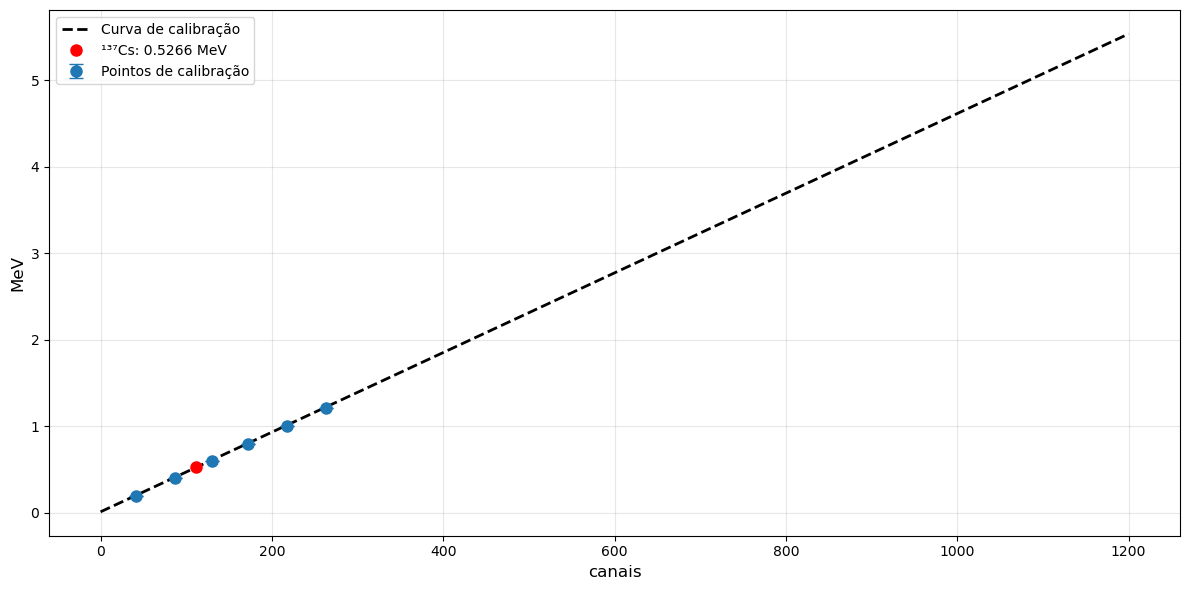

m = 0.0046012035 ± 0.0000363440 MeV/ch
b = 0.0118155699 ± 0.0024023031 MeV


In [29]:
cs_conv_mu = 111.8793 
cs_conv_sigma = 0.0600 

# Cs-137 conversion electron energy
cs_conv_ene = 0.526595 
cs_conv_ene_sigma = 0.004247

pulser_C = np.array([
    41.3786, 
    86.9546, 
    129.6183, 
    172.4128, 
    217.7778, 
    263.3511
])
pulser_C_sigma = np.array([
    0.0237, 
    0.0641, 
    0.0190, 
    0.0651, 
    0.1235, 
    0.1408
])
pulser_D = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.2])

popt, pcov = optimize.curve_fit(linear, pulser_D, pulser_C, sigma=pulser_C_sigma)
perr = np.sqrt(np.diag(pcov))

pulser_C_fit = linear(pulser_D, *popt)

chi2 = compute_chi2(pulser_C, pulser_C_fit, dof=len(pulser_C) - 2)

cs_conv_dial = (cs_conv_mu - popt[1]) / popt[0]
cs_conv_dial_sigma = np.sqrt((cs_conv_sigma / popt[0]) ** 2 + ((cs_conv_mu - popt[1]) * perr[0] / popt[0] ** 2) ** 2 + (perr[1] / popt[0]) ** 2)

kappa = cs_conv_ene / cs_conv_dial
kappa_sigma = np.abs(cs_conv_ene / cs_conv_dial ** 2) * cs_conv_dial_sigma

pulser_energies = kappa * pulser_D
#A incerteza dos dials é 0.01, menor divisão da escala
pulser_energies_sigma = np.sqrt((kappa_sigma * pulser_D) ** 2 + (kappa * 0.01) ** 2)

m = kappa/ popt[0]
m_sigma = np.sqrt((perr[0] * kappa/ popt[0]**2) ** 2 + (kappa_sigma/popt[0]) ** 2)
b = -popt[1] * kappa/popt[0]
b_sigma = np.sqrt((perr[1] * kappa / popt[0]) ** 2 + (popt[1] * kappa_sigma / popt[0]) ** 2 + (popt[1] * kappa * perr[0] / popt[0] ** 2) ** 2)

channels_plot = np.linspace(0, 1200, 1000)
energy_plot = m * channels_plot + b

pulser_energies_calib = m * pulser_C

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_plot, energy_plot, 'k--', linewidth=2, label='Curva de calibração')
ax.errorbar(pulser_C, pulser_energies_calib, yerr=pulser_C_sigma * m, fmt='o', markersize=8, capsize=5, elinewidth=2, label='Pointos de calibração')
ax.plot(cs_conv_mu, cs_conv_ene, 'ro', markersize=8, label=f'¹³⁷Cs: {cs_conv_ene:.4f} MeV')
ax.set_xlabel('canais', fontsize=12)
ax.set_ylabel('MeV', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"m = {m:.10f} ± {m_sigma:.10f} MeV/ch")
print(f"b = {b:.10f} ± {b_sigma:.10f} MeV")

In [30]:
M_CALIB = 0.0046012035
B_CALIB = 0.0118155699
M_CALIB_SIGMA = 0.0000363440
B_CALIB_SIGMA = 0.0024023031

def calib(channels, sigma_channels=None):
    energy = linear(channels, M_CALIB, B_CALIB)
    if sigma_channels is not None:
        sigma_energy = np.sqrt((M_CALIB_SIGMA * channels)**2 + (M_CALIB * sigma_channels)**2 + B_CALIB_SIGMA**2)
    else:
         sigma_energy = np.sqrt((M_CALIB_SIGMA * channels)**2 + B_CALIB_SIGMA**2)
    return energy, sigma_energy

# Espetro Bi

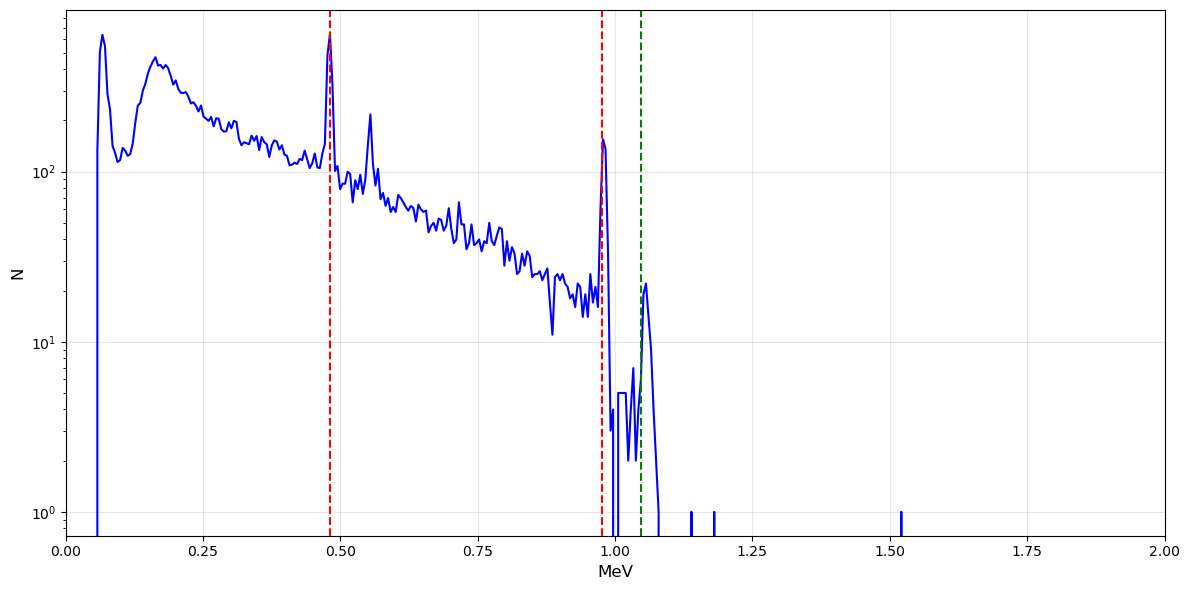

In [31]:
bi_channels, bi_counts = load_spectrum('BIPR3.ASC')
bi_energies, bi_sigma_energies = calib(bi_channels)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(bi_energies, bi_counts, 'b-', linewidth=1.5)
ax.axvline(x=0.4811, color='r', linestyle='--', label='Bi-207: 0.6093 MeV')
ax.axvline(x=0.975645, color='r', linestyle='--', label='Bi-207: 0.975645 MeV')
ax.axvline(x=1.047, color='g', linestyle='--', label='Bi-207: 1.047 MeV')
ax.set_yscale('log')
ax.set_xlim(0, 2)
ax.set_xlabel('MeV', fontsize=12)
ax.set_ylabel('N', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# Identify 4 main peaks
peaks, properties = signal.find_peaks(bi_counts, height=10, distance=5)
peak_heights = properties['peak_heights']
sorted_indices = np.argsort(peak_heights)[::-1][:4]
main_peaks = peaks[sorted_indices]

print("4 Main Peaks of Bi-207 Spectrum:")
for i, peak_idx in enumerate(sorted(main_peaks), 1):
    print(f"Peak {i}: E = {bi_energies[peak_idx]:.4f} MeV, Counts = {bi_counts[peak_idx]:.0f}")

4 Main Peaks of Bi-207 Spectrum:
Peak 1: E = 0.0670 MeV, Counts = 638
Peak 2: E = 0.1637 MeV, Counts = 471
Peak 3: E = 0.2005 MeV, Counts = 344
Peak 4: E = 0.4811 MeV, Counts = 646
